# DOHMH New York City Restaurant Inspection Results

In this file, we analyze the behavior and performance of the self-balancing sampler on the NYC [Restaurant Inspection Dataset](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data) which is available through [NYC Open Data](https://opendata.cityofnewyork.us/).


##### Ideas

To choose a certain bias parameter $\beta$ for our sampler, maybe we could somehow train a model to predict the likelihood of a restaurant to fail a health inspection, and bias our sampler towards the high-risk restaurants. In this case, we may want to keep some of the extraneous features (like Borough, restaurant name, and whatnot) in order to use them as predictive features (e.g. maybe certain restaurants are more prone to health issues due to the kinds of ingredients they tend to use, which require more careful care.)

The health inspectors already have some sort of a biasing towards reinspecting establishments receiving poor scores:


>If the initial score is less than 14 points, the next initial inspection occurs approximately 12 months later; if the higher of the scores is 14-27 points, the next initial  will be 5 to 7 months after re-inspection; if the higher score is 28 or more points, the next initial inspection will occur 3 to 5 months after re-inspection.

Performance analysis:
* Detection delay: how long do we tend to wait before detecting a health concern. 

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style='whitegrid', context='notebook')

import os
from pathlib import Path

workdir = Path(os.getcwd())
data_dir = workdir / 'data'

## Data Schema

The *data/RestaurantInspectionDataDictionary_09242018.xlsx* file gives terse descriptions of the columns in this dataset while the *data/About_NYC_Restaurant_Inspection_Data_on_NYC_OpenData_050222.docx* file gives a broader exposition about what the data set contains. These encapsulate features like the location of the restauarant, contact information, the inspection date, inspection scores, and whatnot. There are a few features we are crucially interested in:

* **CAMIS**: A unique identifier for a specific restaurant.
* **Inspection Date**: Date inspection occurred.
* **Inspection Type**: Inspections are scheduled for various reasons: a pre-permit phase before a restaurant first opens, a periodic inspection, or a scheduled reinspection due to infractions. This field encodes that information. 
* **Score** and **Grade**: A numerical score in $[0, \infty)$ and its corresponding letter grade. Points are awarded for infractions, so low scores are better. Letter grades are assigned from these scores typically as follows $[0, 13] \mapsto A$, $[14, 27] \mapsto B$, and $[28, \infty) \mapsto C$. 


One crucial omission from the dataset: restaurants that go out of business are **removed from the dataset**. We must be a bit careful to handle this sort of surviorship bias. Moreover, when an inspection results in more than one violation, values for associated fields are **repeated for each additional violation record**. Again, we must carefully handle this duplicated data. 

In [ ]:
data_path = data_dir / 'raw' /'DOHMH_New_York_City_Restaurant_Inspection_Results_20260512.csv'
full_df = pd.read_csv(data_path)

In [ ]:
display(list(full_df.columns))

['CAMIS',
 'DBA',
 'BORO',
 'BUILDING',
 'STREET',
 'ZIPCODE',
 'PHONE',
 'CUISINE DESCRIPTION',
 'INSPECTION DATE',
 'ACTION',
 'VIOLATION CODE',
 'VIOLATION DESCRIPTION',
 'CRITICAL FLAG',
 'SCORE',
 'GRADE',
 'GRADE DATE',
 'RECORD DATE',
 'INSPECTION TYPE',
 'Latitude',
 'Longitude',
 'Community Board',
 'Council District',
 'Census Tract',
 'BIN',
 'BBL',
 'NTA',
 'Location']

### Data Filtering, Cleaning, and Imputation

We start by performing some simple data-cleaning and filtering operatings.
* Filter to relevant columns of the dataset. 
* Convert date field to a pandas datetime object.
* Drop rows with missing numerical score AND missing letter grade, or with incomplete letter grade "N". Fill missing grades according to the given map from scores to grades. 
* Split inspection type into a program field (pre-permit, cyclic, etc) and the visit type (initial inspection, reinspection, etc).
* Drop rare inspection program (Interagency task force, accelerated inspection etc) and reduce to two common fields (pre-permit and cycle). The former occurs on initial opening of the establishment, and the latter on a cyclic basis. 
* Drop rare inspection types and restrict to two most common: initial inspections and re-inspections.
* Drop duplicate rows that occur when a single inspection induces several violations. We do so by dropping duplicate (id, date) pairs.


Maybe we should also possible:
*  **Drop re-inspections** (maybe???), which are clearly biased towards worse scores. Namely, only consider initial inspections, 


In [103]:
# filter dataset to include only relevent columns
columns_to_keep = ['CAMIS', 'INSPECTION DATE', 'GRADE', 'SCORE', 'INSPECTION TYPE']
rename_map = {'CAMIS':'id', 'INSPECTION DATE':'date', 'GRADE':'grade', 'SCORE':'score', 'INSPECTION TYPE':'type'}
df = full_df[columns_to_keep].copy()
df.rename(columns=rename_map, inplace=True)

# drop missing rows
mask = df['grade'].isna() & df['score'].isna()
df_filtered = df[~mask]

# fill missing grades using scores
def score_mapper(score):
    '''Converts numerical score to letter grade.'''
    if score <= 13:
        return 'A'
    elif score <= 27:
        return 'B'
    else:
        return 'C'
    
mask = df['score'].isna()
df_filtered.loc[~mask, 'grade'] = df_filtered.loc[~mask, 'score'].apply(score_mapper)
df_filtered.loc[:, 'grade'] = df_filtered['grade'].str.strip()
df_filtered = df_filtered.query('grade != "N"')

# Split inspection type into a program field (pre-permit, cylic, etc) and the visit type (initial inspection, reinspection, etc)
df_filtered[["inspection_program", "inspection_type"]] = (
    df_filtered["type"]
    .str.split("/", n=1, expand=True)
)
df_filtered.loc[:, "inspection_program"] = df_filtered["inspection_program"].str.strip().str.lower()
df_filtered.loc[:, "inspection_type"] = df_filtered["inspection_type"].str.strip().str.lower()
df_filtered.drop(columns=['type'], inplace=True)

# Drop rare programs and simplify pre-permit (operational vs non-operational) into a single pre-permit value
mask = df_filtered['inspection_program'].str.contains('cycle') | df_filtered['inspection_program'].str.contains('pre-permit')
df_filtered = df_filtered[mask]

def program_map(name):
    if 'cycle' in name:
        return 'cycle'
    else:
        return 'pre-permit'
    
df_filtered['inspection_program'] = df_filtered['inspection_program'].apply(program_map)

# Drop rare inspection types (consider only initial inspections are reinspections)
valid_inspection_types = ['initial inspection', 're-inspection']
df_filtered = df_filtered.query('inspection_type in @valid_inspection_types')

# convert date to pandas datetime object
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# Drop duplicate (id, date) pairs
df_filtered = df_filtered.drop_duplicates(subset=["id", "date"])

display(df_filtered.head())
print("Initial shape: ", df.shape)
print('Shape after filtering: ', df_filtered.shape)

# display(df_filtered['inspection_type'].value_counts())
# display(df_filtered['inspection_program'].value_counts())

,id,date,grade,score,inspection_program,inspection_type
15,41304673,2026-03-21,C,34.0,cycle,initial inspection
19,50136100,2025-06-12,B,24.0,cycle,initial inspection
21,50032642,2024-12-17,A,12.0,cycle,re-inspection
29,50141096,2024-10-13,A,0.0,pre-permit,initial inspection
40,41305723,2025-02-19,A,10.0,cycle,re-inspection


Initial shape:  (296210, 5)
Shape after filtering:  (80015, 6)


In [115]:
savepath = data_dir / 'processed' / "health_inspections_filtered.parquet"

# save filtered dataset
df_filtered.to_parquet(savepath, index=False)

#optionally, load filtered dataset
#df_filtered = pd.read_parquet(savepath)

### Data Visualization

Here we seek to do a little bit of data-exploration. A summary of my findings are:
* Re-inspections are are biased towards *better scores*. This is possibly an effect of survivorship bias, as we saw failed restaurants are removed from the dataset.

Q: How does the inspection score depend on the inspection type (initial inspection versus re-inspection)?



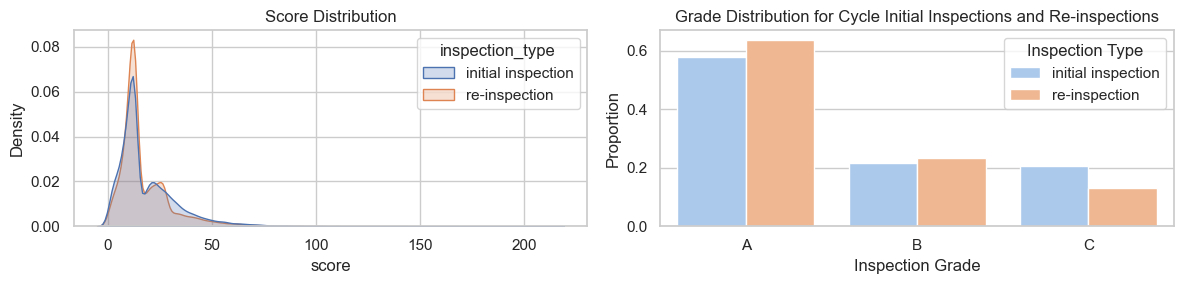

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Score distribution 
ax = axes[0]
sns.kdeplot(data=df_filtered, 
             x='score',
             hue='inspection_type',
             fill=True,
             common_norm=False,
             ax=ax)

ax.set_title('Score Distribution')

# grade distribution
ax = axes[1]
grade_dist = df_filtered.groupby('inspection_type')['grade'].value_counts(normalize=True).reset_index()

sns.barplot(
    data=grade_dist,
    x="grade",
    y="proportion",
    hue="inspection_type",
    order=['A', 'B', 'C'],
    palette="pastel",
    ax=ax,
)

ax.set_xlabel("Inspection Grade")
ax.set_ylabel("Proportion")
ax.set_title("Grade Distribution for Cycle Initial Inspections and Re-inspections")
ax.legend(title="Inspection Type")

plt.tight_layout()
plt.show()

Q: How often does a specific restaurant appear in the dataset, and what is the typical time between inspections?

It seems like a typical restaurant appears around 3 times in the dataset, so we have two "inter-inspection" windows to consider. Certainly not a lot, but possibly sufficient for our purposes.

mean: 2.90, std_dev: 1.32


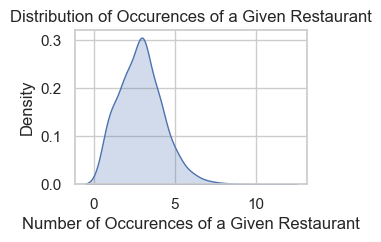

In [113]:
rest_df = df_filtered.groupby('id').size()

plt.figure(figsize=(3,2))
sns.kdeplot(rest_df, fill=True, bw_adjust=3)
plt.title("Distribution of Occurences of a Given Restaurant")
plt.xlabel("Number of Occurences of a Given Restaurant")

print(f"mean: {rest_df.mean():.2f}, std_dev: {rest_df.std():.2f}")

In [100]:
rest_df.head()

id
30075445    11
30191841    10
40356018     3
40356483    20
40356731     9
dtype: int64

In [102]:
id = 30075445
temp = df_filtered.query('id == @id').sort_values('date', ascending=True)
temp.head()

,id,date,grade,score,inspection_program,inspection_type
26621,30075445,2023-08-01,C,38.0,cycle,initial inspection
247016,30075445,2023-08-01,C,38.0,cycle,initial inspection
247591,30075445,2023-08-01,C,38.0,cycle,initial inspection
100823,30075445,2023-08-22,A,12.0,cycle,re-inspection
183837,30075445,2023-08-22,A,12.0,cycle,re-inspection
